In [3]:
# We will download the Energy Efficiency Dataset from Kaggle
!pip install kagglehub

In [4]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

print("Path to dataset files:", path)

# List all files/folders in the downloaded directory
print(os.listdir(path))

Path to dataset files: C:\Users\gladys.fontanilla\.cache\kagglehub\datasets\elikplim\eergy-efficiency-dataset\versions\1
['ENB2012_data.csv']


In [5]:
# Join into the directory path
file_csv='ENB2012_data.csv'
energy_csv=os.path.join(path, file_csv)

In [6]:
# We will first conduct an exploratory data analysis to get an idea about the relationships between features and target variables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
# Convert the data into pandas dataframe
df_energy=pd.read_csv(energy_csv)
print(df_energy.info())
df_energy.rename(columns={'X1':'Relative Compactness', 'X2':'Surface Area', 'X3':'Wall Area', 'X4':'Roof Area', 'X6':'Orientation', 'X5':'Overall Height', 'X7':'Glazing Area', 'X8':'Glazing Area Distribution', 'Y1': 'Heating Load', 'Y2':'Cooling Load'}, inplace=True)
df_energy.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [8]:
# X7 and X8 seems to be categorical, checking the uniqe values on each
print(df_energy['Orientation'].value_counts())
print(df_energy['Glazing Area Distribution'].value_counts())

Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64
Glazing Area Distribution
1    144
2    144
4    144
3    144
5    144
0     48
Name: count, dtype: int64


Text(0.5, 1.0, 'Cooling Load Histogram')

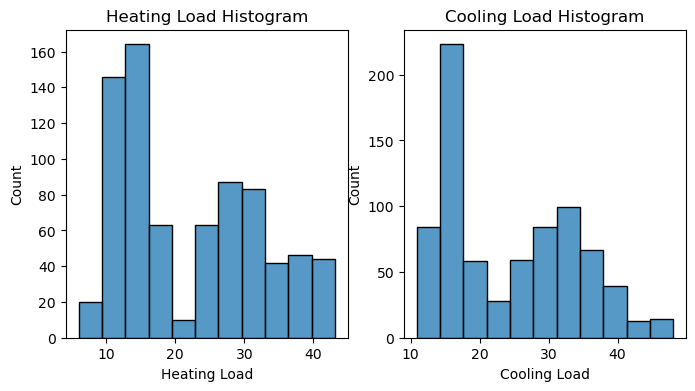

In [9]:
# Check first the distribution of the target variable
fig, axes=plt.subplots(nrows=1, ncols=2, figsize=(8,4))
sns.histplot(data=df_energy, x='Heating Load', kde=False, ax=axes[0])
axes[0].set_title("Heating Load Histogram")

sns.histplot(data=df_energy, x='Cooling Load', kde=False, ax=axes[1])
axes[1].set_title("Cooling Load Histogram")
# For starters, we will try to model the heating load, Y1

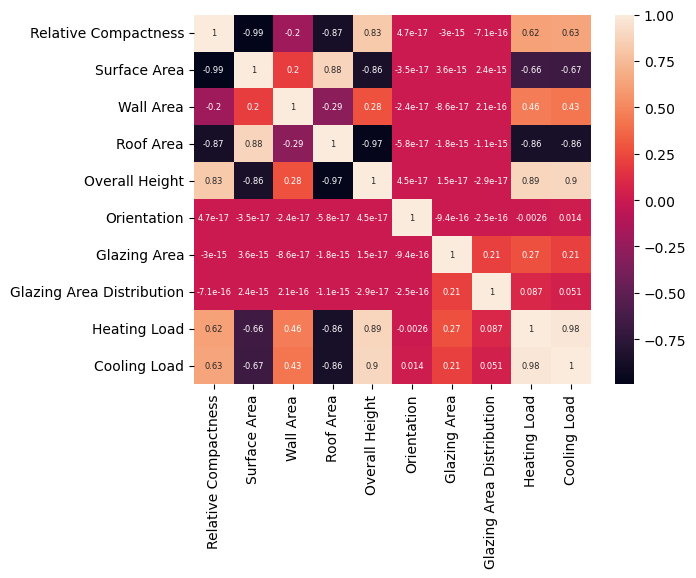

In [10]:
#Checking the correlation
sns.heatmap(df_energy.corr(), linecolor='white', annot=True, annot_kws={"size": 6})
plt.show()

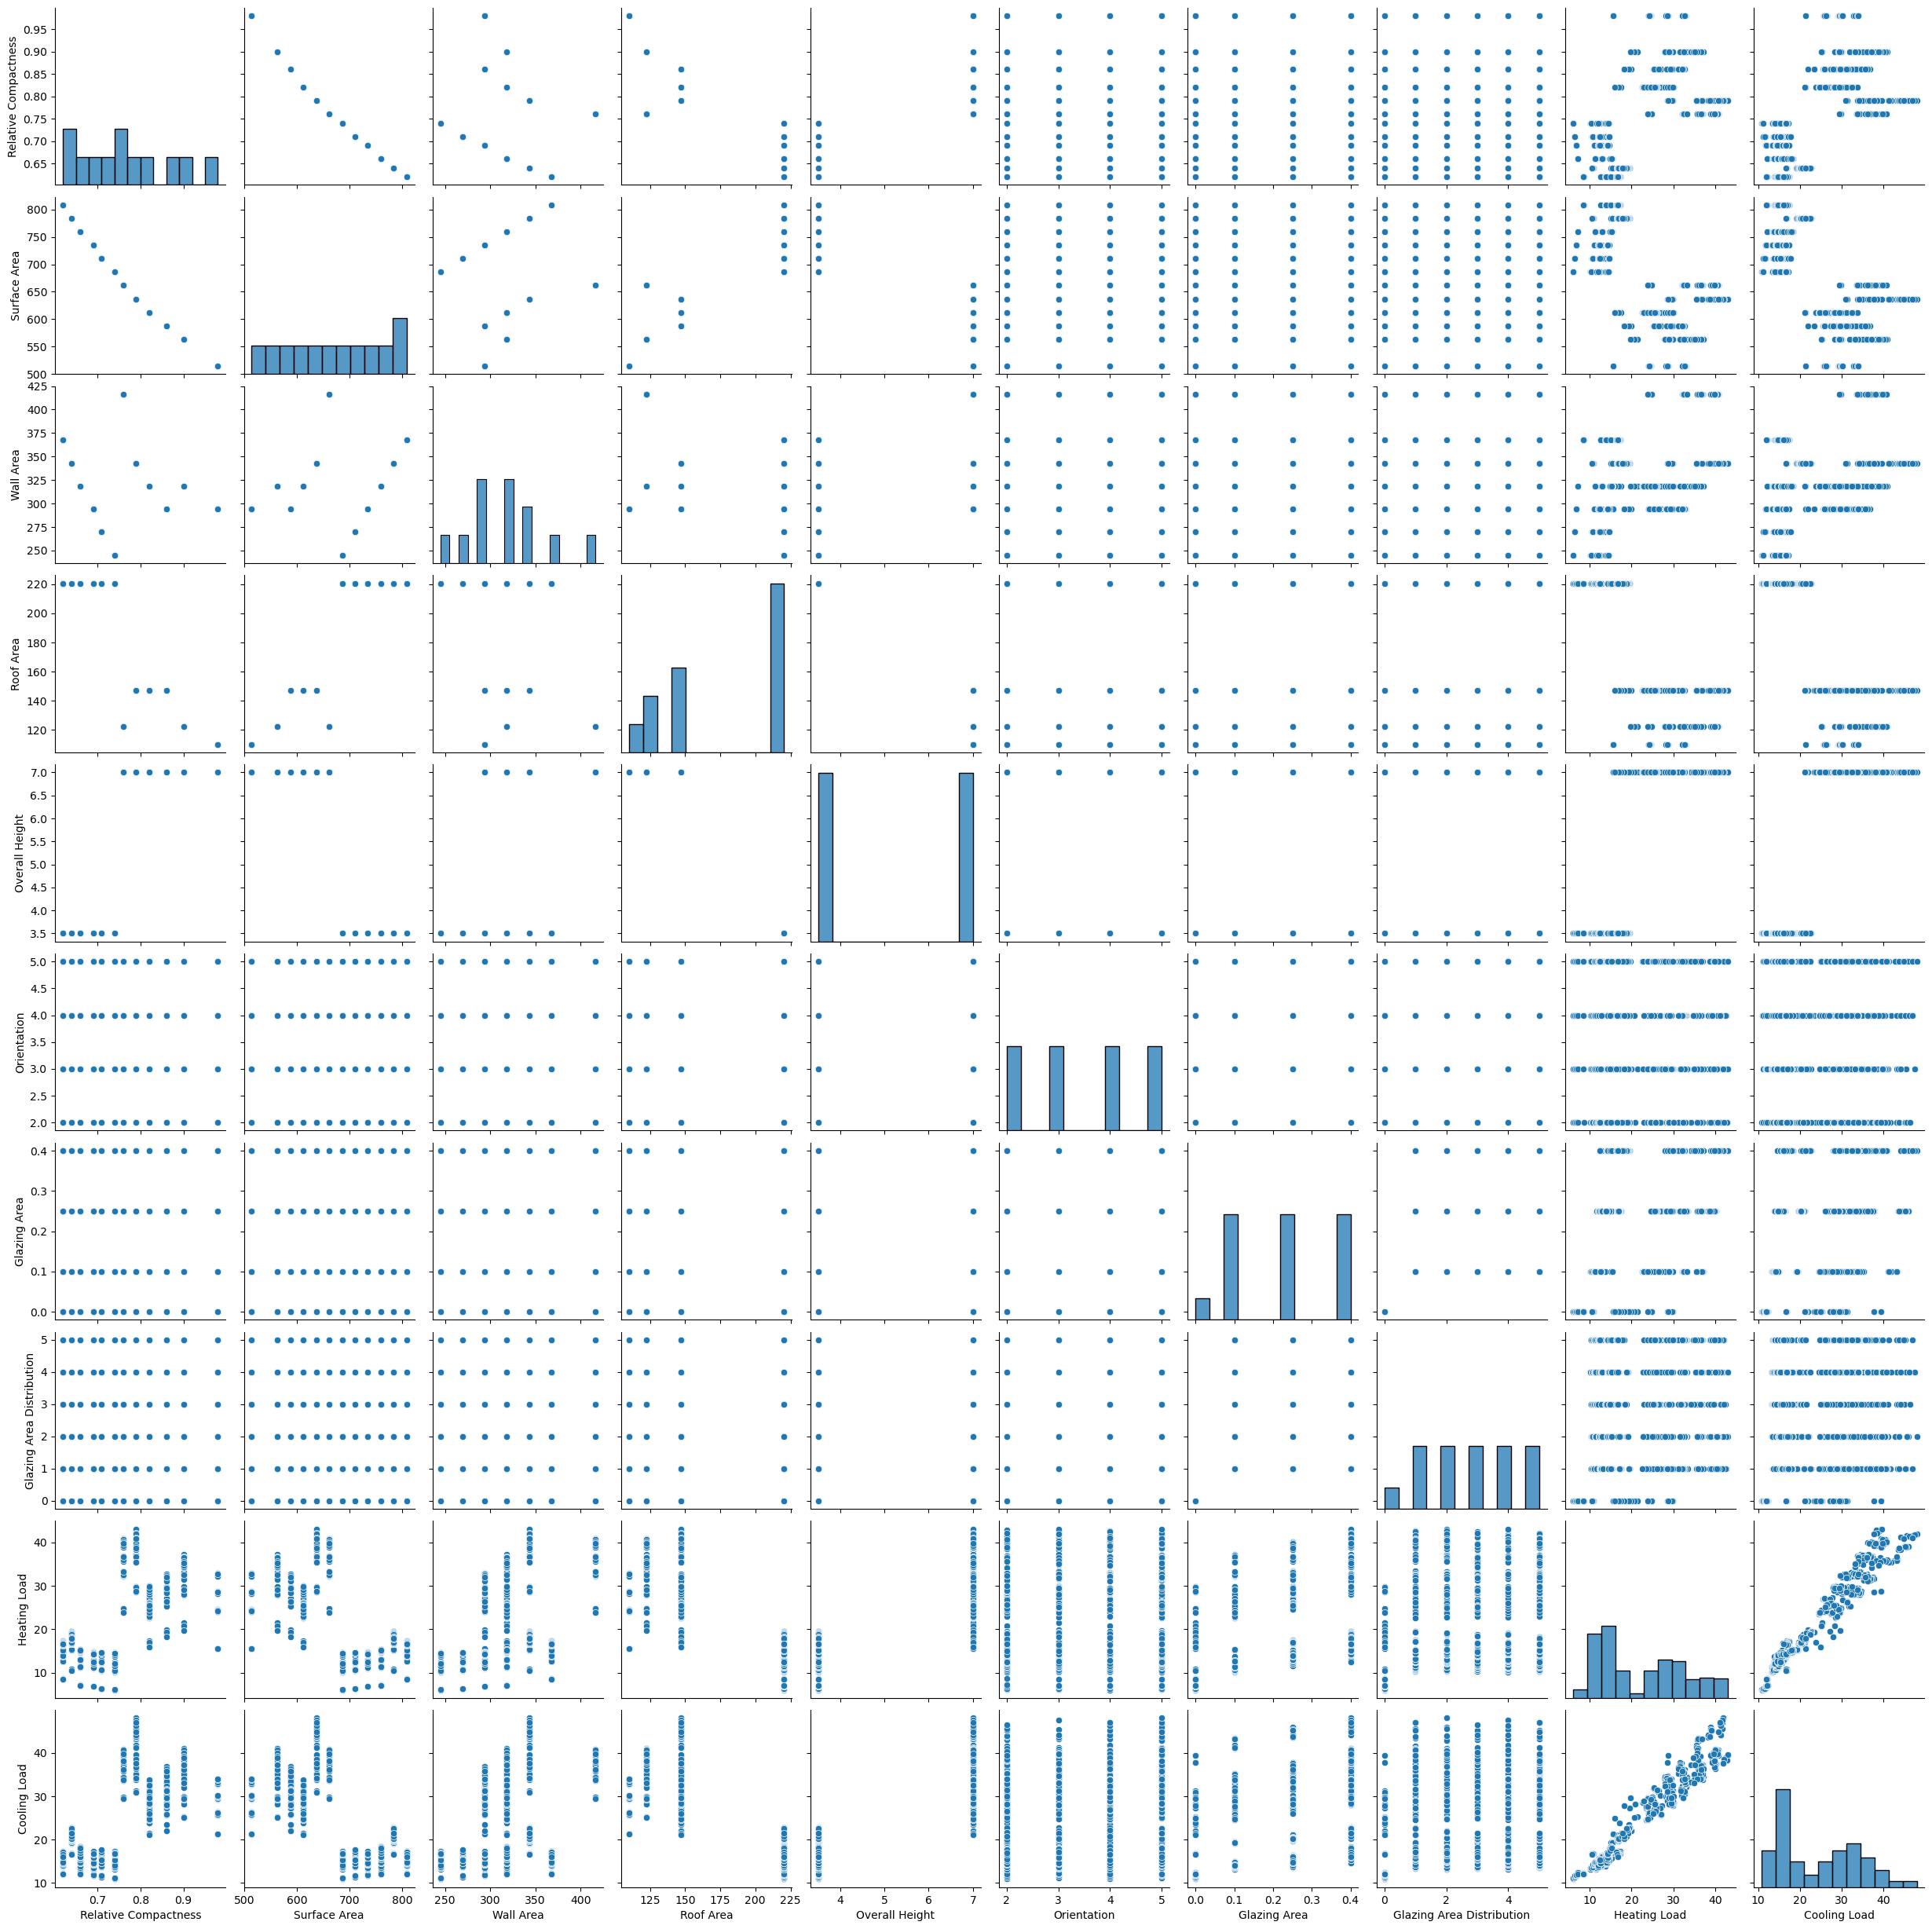

In [11]:
# Pairplot
sns.pairplot(df_energy)

In [12]:
!pip install scikit-learn

In [13]:
X = df_energy.drop(columns=['Heating Load', 'Cooling Load'])
y = df_energy['Heating Load']

In [14]:
#Preprocessing and training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# We first identify the categorical and numerical features
numeric_features=["Relative Compactness", "Surface Area", "Wall Area",
    "Roof Area", "Overall Height", "Glazing Area"]
categorical_features=["Orientation", "Glazing Area Distribution"]

In [16]:
# Create a pipeline to transform the features
numerical_transformer=Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer=Pipeline(steps=[("onehot", OneHotEncoder(drop="first"))])
preprocessor=ColumnTransformer(transformers=[("num", numerical_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

In [17]:
# Using the train-test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# We use linear regression as a base model to check if the relationships are roughly linear before using complex models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
lin_reg=Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_train, y_train)
y_pred=lin_reg.predict(X_test)

#Metrics
print("RMSE: \n", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2: \n", r2_score(y_test, y_pred))

RMSE: 
 2.872295759280087
R^2: 
 0.920848505580741


In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

In [20]:
# Now we do hyperparameter finetuning
ridge=Pipeline(steps=[("preprocessor", preprocessor), ("model", Ridge())])
param_grid={"model__alpha": [0.01, 0.1,1,100]}

grid_ridge=GridSearchCV(ridge, param_grid,cv=5, scoring="neg_root_mean_squared_error")
grid_ridge.fit(X_train, y_train)
best_model=grid_ridge.best_estimator_
print("Best alpha: \n", grid_ridge.best_params_)

Best alpha: 
 {'model__alpha': 0.1}


In [21]:
# Model Evaluation
y_pred_ridge=best_model.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae=mean_absolute_error(y_test, y_pred_ridge)
r2=r2_score(y_test, y_pred_ridge)

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R^2: {r2:.5f}")

RMSE: 2.87507
MAE: 2.06145
R^2: 0.92070


In [22]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [23]:
# Hyperparameter tuning using random forest for non linear relationships
rf=Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestRegressor(random_state=42))])
params_grid={"model__n_estimators": [100,200], "model__max_depth": [5,8], "model__min_samples_split": [8,12], "model__min_samples_leaf": [4,3]}

grid_rf=GridSearchCV(rf, params_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf=grid_rf.best_estimator_

In [24]:
# Model Evaluation
y_pred_rf=best_rf.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae=mean_absolute_error(y_test, y_pred_rf)
r2=r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.3f}")

RMSE: 0.59
MAE: 0.39
R^2: 0.997


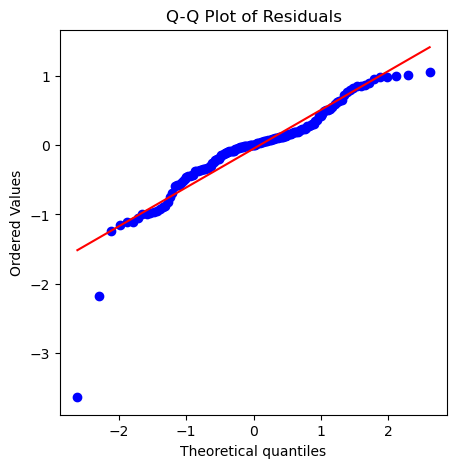

In [25]:
# Adding a Q-Q plot
import scipy.stats as stats

plt.figure(figsize=(5,5))
stats.probplot(y_test - y_pred_rf, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [26]:
#Now we check for overfitting
y_train_pred=best_rf.predict(X_train)
print("Train RMSE: ", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Train RMSE:  0.5275532540984474
Test RMSE:  0.5931401247152019


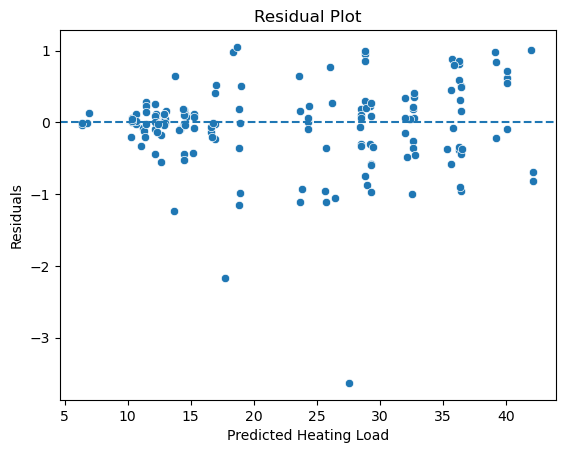

In [27]:
# Residual analysis
residuals=y_test-y_pred_rf
plt.figure()
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Heating Load")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

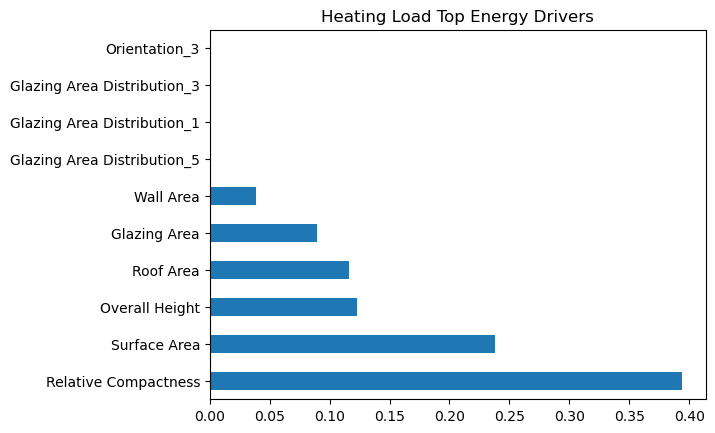

In [40]:
# Feature Importance
importances=best_rf.named_steps["model"].feature_importances_
feature_names=(numeric_features+list(best_rf.named_steps["preprocessor"].transformers_[1][1].named_steps["onehot"].get_feature_names_out(categorical_features)))

#Convert into dataframe

fi=pd.Series(importances, index=feature_names).sort_values(ascending=False)
fi.head(10).plot(kind="barh")
plt.title("Heating Load Top Energy Drivers")
plt.show()

#save this into csv, save to project directory
fi.to_csv("heating_load_feature_importance.csv", index=True)

In [29]:
# Now we do likewise to predict the cooling load 
X = df_energy.drop(columns=['Heating Load', 'Cooling Load'])
yc = df_energy['Cooling Load']
# Using the train-test split
Xc_train, Xc_test, yc_train, yc_test=train_test_split(X, yc, test_size=0.2, random_state=42)

In [30]:
lin_reg=Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
lin_reg.fit(Xc_train, yc_train)
yc_pred=lin_reg.predict(Xc_test)

#Metrics
print("RMSE: \n", np.sqrt(mean_squared_error(yc_test, yc_pred)))
print("MAE: \n", mean_absolute_error(yc_test, yc_pred))
print("R^2: \n", r2_score(yc_test, yc_pred))


RMSE: 
 3.119754933464355
MAE: 
 2.180511908625354
R^2: 
 0.8949583305630099


In [31]:
# We will try hyperparameter alpha fine tuning

grid_ridge_c=GridSearchCV(ridge, param_grid,cv=5, scoring="neg_root_mean_squared_error")
grid_ridge_c.fit(Xc_train, yc_train)
best_model=grid_ridge.best_estimator_
print("Best alpha: \n", grid_ridge.best_params_)

Best alpha: 
 {'model__alpha': 0.1}


In [32]:
# Model Evaluation for cooling 
yc_pred_ridge=best_model.predict(Xc_test)
rmse_c=np.sqrt(mean_squared_error(yc_test, yc_pred_ridge))
mae_c=mean_absolute_error(yc_test, yc_pred_ridge)
r2_c=r2_score(yc_test, yc_pred_ridge)

print(f"RMSE: {rmse_c:.5f}")
print(f"MAE: {mae_c:.5f}")
print(f"R^2: {r2_c:.5f}")

RMSE: 4.17302
MAE: 3.19511
R^2: 0.81206


In [33]:
# With R^2 lower, we can try random forest
grid_rf_c=GridSearchCV(rf, params_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_rf_c.fit(Xc_train, yc_train)
best_rf_c=grid_rf_c.best_estimator_

In [34]:
# Model Evaluation
y_pred_rf_c=best_rf_c.predict(Xc_test)
rmse_rf_c=np.sqrt(mean_squared_error(yc_test, y_pred_rf_c))
mae_rf_c=mean_absolute_error(yc_test, y_pred_rf_c)
r2_rf_c=r2_score(yc_test, y_pred_rf_c)

print(f"RMSE: {rmse_rf_c:.2f}")
print(f"MAE: {mae_rf_c:.2f}")
print(f"R^2: {r2_rf_c:.3f}")

RMSE: 1.87
MAE: 1.23
R^2: 0.962


In [35]:
#Now we check for overfitting
y_train_pred_c=best_rf_c.predict(Xc_train)
print("Train RMSE: ", np.sqrt(mean_squared_error(yc_train, y_train_pred_c)))
print("Test RMSE: ", np.sqrt(mean_squared_error(yc_test, y_pred_rf_c)))

Train RMSE:  1.5213755202709618
Test RMSE:  1.865065372026443


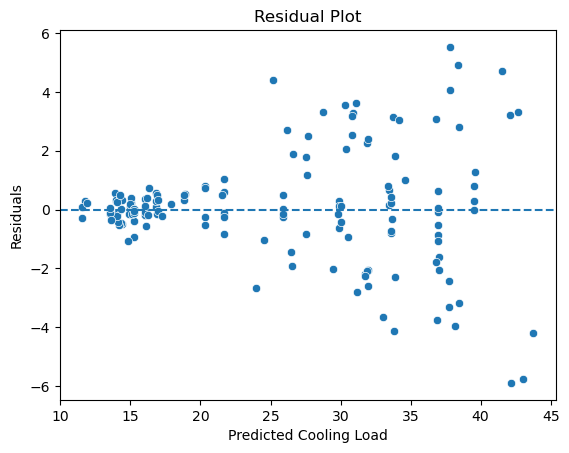

In [36]:
# Residual analysis
residuals_c=yc_test-y_pred_rf_c
plt.figure()
sns.scatterplot(x=y_pred_rf_c, y=residuals_c)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Cooling Load")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

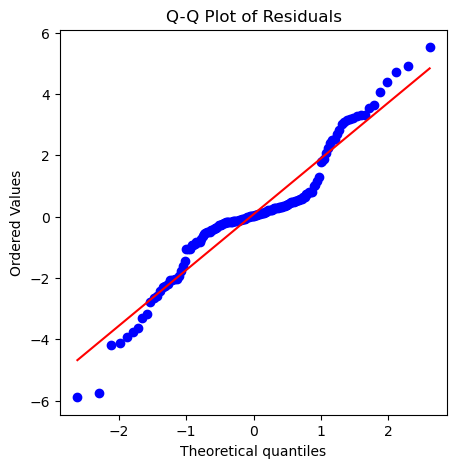

In [37]:
#Adding a Q-Q plot
plt.figure(figsize=(5,5))
stats.probplot(yc_test - y_pred_rf_c, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

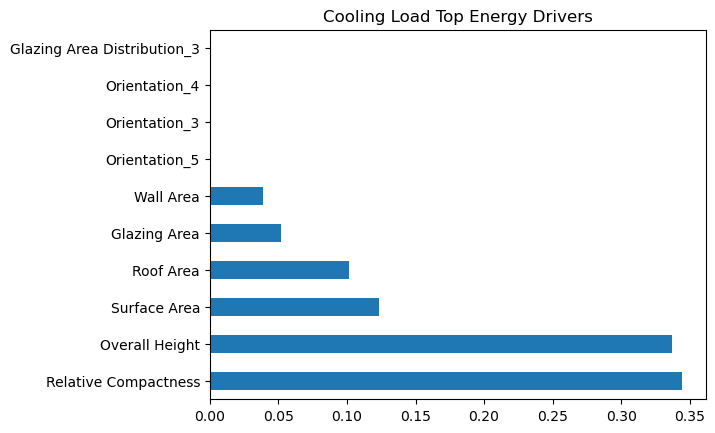

In [ ]:
# Feature Importance
importances_c=best_rf_c.named_steps["model"].feature_importances_
feature_names_c=(numeric_features+list(best_rf_c.named_steps["preprocessor"].transformers_[1][1].named_steps["onehot"].get_feature_names_out(categorical_features)))

#Convert into dataframe

fi_c=pd.Series(importances_c, index=feature_names_c).sort_values(ascending=False)
fi_c.head(10).plot(kind="barh")
plt.title("Cooling Load Top Energy Drivers")
plt.show()



In [39]:
#Save this into csv, save to local directory 
fi_c.to_csv("cooling_load_feature_importance.csv", index=True)
